In [243]:
import warnings
warnings.filterwarnings('ignore')

In [244]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

In [245]:
data = pd.read_stata('usa_00006.dta')
data.head()

,year,multyear,sample,serial,cbserial,hhwt,cluster,stateicp,countyfip,strata,...,pernum,perwt,sex,age,race,raced,hispan,hispand,educ,educd
0,2023,2019,"2019-2023, acs 5-year",1,2.019010e+12,2,2.023000e+12,alabama,0,260001,...,1,2,male,39,black/african american,black/african american,not hispanic,not hispanic,grade 10,grade 10
1,2023,2019,"2019-2023, acs 5-year",2,2.019010e+12,14,2.023000e+12,alabama,0,70001,...,1,14,female,21,white,white,not hispanic,not hispanic,grade 10,grade 10
2,2023,2019,"2019-2023, acs 5-year",3,2.019010e+12,4,2.023000e+12,alabama,15,80001,...,1,4,male,19,black/african american,black/african american,not hispanic,not hispanic,1 year of college,"1 or more years of college credit, no degree"
3,2023,2019,"2019-2023, acs 5-year",4,2.019010e+12,17,2.023000e+12,alabama,15,80001,...,1,17,male,77,white,white,not hispanic,not hispanic,grade 9,grade 9
4,2023,2019,"2019-2023, acs 5-year",5,2.019010e+12,11,2.023000e+12,alabama,97,280301,...,1,11,male,41,black/african american,black/african american,not hispanic,not hispanic,grade 9,grade 9


In [246]:
data.shape

(15912393, 21)

In [247]:
np.unique(data['age'])

array(['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19',
       '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29',
       '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39',
       '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49',
       '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59',
       '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69',
       '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79',
       '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89',
       '9', '90 (90+ in 1980 and 1990)', '91', '92', '93', '94', '95',
       '96', '97', 'less than 1 year old'], dtype=object)

In [248]:
data['age'] = data['age'].map(lambda x: 90 if x == '90 (90+ in 1980 and 1990)' else (
0 if x == 'less than 1 year old' else int(x)))
data['age'] = data['age'].astype(int)
data['age']

0           39
1           21
2           19
3           77
4           41
            ..
15912388    53
15912389    66
15912390    63
15912391    63
15912392    66
Name: age, Length: 15912393, dtype: int64

In [249]:
data[data['age'].astype(int)>=18]['educ'].value_counts()

educ
grade 12                     4699461
4 years of college           2574554
1 year of college            1781890
5+ years of college          1665552
2 years of college           1081074
grade 5, 6, 7, or 8           241837
grade 11                      240262
n/a or no schooling           220255
grade 10                      167318
grade 9                       128750
nursery school to grade 4      52424
Name: count, dtype: int64

In [250]:
data = data[data['age'].astype(int)>=18]

In [251]:
data.shape

(12853377, 21)

In [252]:
data['age'] = data['age'].astype(int)

In [253]:
data['age'] = data['age'].map(lambda x: 1 if x < 30 else
                                 (2 if x < 40 else (
                                 3 if x < 50 else (
                                 4 if x < 60 else (
                                 5 if x < 70 else 6)))))

In [254]:
data['race'].value_counts()

race
white                               9104714
black/african american              1169670
two major races                      952206
other race, nec                      625887
other asian or pacific islander      553919
chinese                              198980
american indian or alaska native     144498
three or more major races             66445
japanese                              37058
Name: count, dtype: int64

In [255]:
data['hispan'].value_counts()

hispan
not hispanic    11116912
mexican          1011506
other             485349
puerto rican      157944
cuban              81666
Name: count, dtype: int64

In [256]:
code_race = {
    'white': 0,
    'black': 1,
    'aapi': 2,
    'hispanic': 3,
    'unknown': 4,
    'other': 5,
    'natam': 6,
    'mixed': 7
}

def id_race(race, hisp):
    if hisp != 'not hispanic':
        return 3
    else:
        if race == 'white':
            return 0
        elif race == 'black/african american':
            return 1
        elif race in ['chinese', 'japanese', 'other asian or pacific islander']:
            return 2
        elif race == 'american indian or alaska native':
            return 6
        elif race == 'other race, nec':
            return 5
        elif race in ['three or more major races', 'two major races']:
            return 7
        else:
            return 4

In [257]:
data['race_id'] = data[['race', 'hispan']].apply(lambda x: id_race(x['race'], x['hispan']), axis=1)

In [258]:
data['race'] = data['race_id']

In [259]:
np.unique(data['educ'])

array(['1 year of college', '2 years of college', '4 years of college',
       '5+ years of college', 'grade 10', 'grade 11', 'grade 12',
       'grade 5, 6, 7, or 8', 'grade 9', 'n/a or no schooling',
       'nursery school to grade 4'], dtype=object)

In [260]:
## Education
## 1: Less than high school grad, 2: High school grad,
## 3: Some college, 4: College grad
def id_edu(educ):
    if educ in ['grade 5, 6, 7, or 8', 'grade 9', 'n/a or no schooling',
       'nursery school to grade 4', 'grade 10', 'grade 11']:
        return 1
    elif educ == 'grade 12':
        return 2
    elif educ in ['1 year of college', '2 years of college']:
        return 3
    elif educ in ['4 years of college',
       '5+ years of college']:
        return 4
    else:
        return 3

In [261]:
data['edu'] = data['educ'].map(id_edu)

In [262]:
data['edu'].value_counts()

edu
2    4699461
4    4240106
3    2862964
1    1050846
Name: count, dtype: int64

(array([9714388., 2261122.,  514979.,   56399.,   51382.,  148742.,
          59577.,       0.,   21103.,   25685.]),
 array([  0.,  81., 162., 243., 324., 405., 486., 567., 648., 729., 810.]),
 <BarContainer object of 10 artists>)

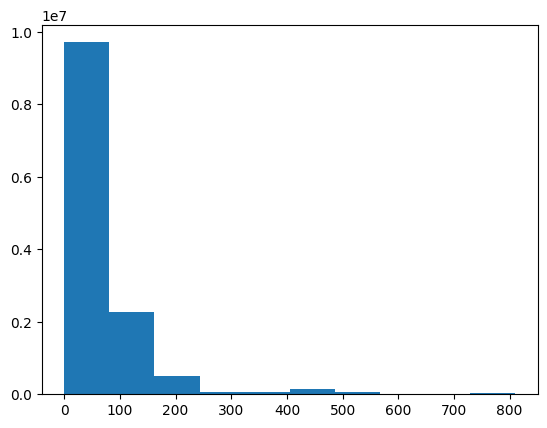

In [263]:
plt.hist(data['countyfip'])

In [264]:
# data['countyicp'] = data['countyicp'].astype(str)
# data = data[data['countyicp'].apply(lambda x: x[:2]=='71')]
# data.head()

In [265]:
data.shape

(12853377, 23)

In [266]:
data['race'].value_counts()

race
0    8624801
3    1736465
1    1143899
2     779332
7     416492
6     103475
5      48913
Name: count, dtype: int64

In [267]:
data = data[data['stateicp']=='california']
data.head()

,year,multyear,sample,serial,cbserial,hhwt,cluster,stateicp,countyfip,strata,...,sex,age,race,raced,hispan,hispand,educ,educd,race_id,edu
770843,2023,2019,"2019-2023, acs 5-year",350027,2.019010e+12,6,2.023004e+12,california,37,370406,...,female,4,1,black/african american,not hispanic,not hispanic,grade 12,"some college, but less than 1 year",1,2
770844,2023,2019,"2019-2023, acs 5-year",350028,2.019010e+12,7,2.023004e+12,california,73,732206,...,male,5,0,white,not hispanic,not hispanic,grade 12,regular high school diploma,0,2
770845,2023,2019,"2019-2023, acs 5-year",350029,2.019010e+12,6,2.023004e+12,california,59,592306,...,female,1,0,white,not hispanic,not hispanic,grade 12,regular high school diploma,0,2
770846,2023,2019,"2019-2023, acs 5-year",350030,2.019010e+12,23,2.023004e+12,california,71,710706,...,male,4,0,white,not hispanic,not hispanic,grade 10,grade 10,0,1
770847,2023,2019,"2019-2023, acs 5-year",350031,2.019010e+12,21,2.023004e+12,california,89,890006,...,female,1,0,white,not hispanic,not hispanic,grade 12,regular high school diploma,0,2


In [268]:
data.shape

(1496723, 23)

In [269]:
np.unique(data['countyfip'])

array([  0,   1,   7,  13,  17,  19,  23,  25,  29,  31,  37,  39,  41,
        47,  55,  59,  61,  65,  67,  71,  73,  75,  77,  79,  81,  83,
        85,  87,  89,  95,  97,  99, 107, 111, 113], dtype=int16)

In [270]:
np.unique(data['countyfip']).shape

(35,)

In [271]:
data['countyfip'].value_counts()

countyfip
37     395570
73     122957
59     119923
65      88246
85      79079
71      70824
1       67769
67      59130
0       56975
13      40892
75      34523
111     33789
19      32680
81      30822
29      28718
77      26193
97      19928
99      18119
83      17925
95      16916
61      16095
107     15160
79      11692
87      11485
41       9765
47       9193
7        8762
113      8719
89       8100
17       7284
55       6741
31       6087
23       5949
25       5456
39       5257
Name: count, dtype: int64

In [272]:
data['fips'] = 6000 + data['countyfip']
data['fips']

770843     6037
770844     6073
770845     6059
770846     6071
770847     6089
           ... 
2624265    6075
2624266    6067
2624267    6067
2624270    6013
2624271    6037
Name: fips, Length: 1496723, dtype: int16

In [273]:
pres = pd.read_csv('ca_pres_res.csv')

In [274]:
pres.head()

,Unnamed: 0,year,state,state_po,county_name,county_fips,office,candidate,party,candidatevotes,totalvotes,version,mode,county_full,level_0,county,vap,biden_vote_pct,countyicp
0,0,2020,CALIFORNIA,CA,ALAMEDA,6001.0,US PRESIDENT,JOSEPH R BIDEN JR,DEMOCRAT,617659,770070,20250821,TOTAL,ALAMEDA COUNTY,1,ALAMEDA COUNTY,1338388.0,0.461495,71001
1,1,2020,CALIFORNIA,CA,ALPINE,6003.0,US PRESIDENT,JOSEPH R BIDEN JR,DEMOCRAT,476,741,20250821,TOTAL,ALPINE COUNTY,2,ALPINE COUNTY,1009.0,0.471754,71003
2,2,2020,CALIFORNIA,CA,AMADOR,6005.0,US PRESIDENT,JOSEPH R BIDEN JR,DEMOCRAT,8153,22304,20250821,TOTAL,AMADOR COUNTY,3,AMADOR COUNTY,34042.0,0.239498,71005
3,3,2020,CALIFORNIA,CA,BUTTE,6007.0,US PRESIDENT,JOSEPH R BIDEN JR,DEMOCRAT,50426,102066,20250821,TOTAL,BUTTE COUNTY,4,BUTTE COUNTY,168339.0,0.299550,71007
4,4,2020,CALIFORNIA,CA,CALAVERAS,6009.0,US PRESIDENT,JOSEPH R BIDEN JR,DEMOCRAT,10046,27164,20250821,TOTAL,CALAVERAS COUNTY,5,CALAVERAS COUNTY,37337.0,0.269063,71009


In [275]:
data = pd.merge(left=data, right=pres[['county_fips', 'biden_vote_pct', 'level_0']], left_on='fips', right_on='county_fips', how='inner')
data.head()

,year,multyear,sample,serial,cbserial,hhwt,cluster,stateicp,countyfip,strata,...,hispan,hispand,educ,educd,race_id,edu,fips,county_fips,biden_vote_pct,level_0
0,2023,2019,"2019-2023, acs 5-year",350027,2.019010e+12,6,2.023004e+12,california,37,370406,...,not hispanic,not hispanic,grade 12,"some college, but less than 1 year",1,2,6037,6037.0,0.380523,19
1,2023,2019,"2019-2023, acs 5-year",350028,2.019010e+12,7,2.023004e+12,california,73,732206,...,not hispanic,not hispanic,grade 12,regular high school diploma,0,2,6073,6073.0,0.369772,37
2,2023,2019,"2019-2023, acs 5-year",350029,2.019010e+12,6,2.023004e+12,california,59,592306,...,not hispanic,not hispanic,grade 12,regular high school diploma,0,2,6059,6059.0,0.323063,30
3,2023,2019,"2019-2023, acs 5-year",350030,2.019010e+12,23,2.023004e+12,california,71,710706,...,not hispanic,not hispanic,grade 10,grade 10,0,1,6071,6071.0,0.279833,36
4,2023,2019,"2019-2023, acs 5-year",350031,2.019010e+12,21,2.023004e+12,california,89,890006,...,not hispanic,not hispanic,grade 12,regular high school diploma,0,2,6089,6089.0,0.209042,45


In [276]:
d1 = pd.read_csv('reg_dfs/reg_df_Q12.csv')

In [277]:
region_to_cnty = pd.read_csv('region_to_cnty.csv')
region_to_cnty.head(2)

,Unnamed: 0,region,CNTY,count
0,0,6,19,1775
1,1,9,37,973


In [278]:
data = pd.merge(left=data, right=region_to_cnty[['region', 'CNTY']], left_on='level_0', right_on='CNTY', how='left')
data.head()

,year,multyear,sample,serial,cbserial,hhwt,cluster,stateicp,countyfip,strata,...,educ,educd,race_id,edu,fips,county_fips,biden_vote_pct,level_0,region,CNTY
0,2023,2019,"2019-2023, acs 5-year",350027,2.019010e+12,6,2.023004e+12,california,37,370406,...,grade 12,"some college, but less than 1 year",1,2,6037,6037.0,0.380523,19,6,19
1,2023,2019,"2019-2023, acs 5-year",350028,2.019010e+12,7,2.023004e+12,california,73,732206,...,grade 12,regular high school diploma,0,2,6073,6073.0,0.369772,37,9,37
2,2023,2019,"2019-2023, acs 5-year",350029,2.019010e+12,6,2.023004e+12,california,59,592306,...,grade 12,regular high school diploma,0,2,6059,6059.0,0.323063,30,8,30
3,2023,2019,"2019-2023, acs 5-year",350030,2.019010e+12,23,2.023004e+12,california,71,710706,...,grade 10,grade 10,0,1,6071,6071.0,0.279833,36,5,36
4,2023,2019,"2019-2023, acs 5-year",350031,2.019010e+12,21,2.023004e+12,california,89,890006,...,grade 12,regular high school diploma,0,2,6089,6089.0,0.209042,45,3,45


In [279]:
data.columns.values

array(['year', 'multyear', 'sample', 'serial', 'cbserial', 'hhwt',
       'cluster', 'stateicp', 'countyfip', 'strata', 'gq', 'pernum',
       'perwt', 'sex', 'age', 'race', 'raced', 'hispan', 'hispand',
       'educ', 'educd', 'race_id', 'edu', 'fips', 'county_fips',
       'biden_vote_pct', 'level_0', 'region', 'CNTY'], dtype=object)

In [280]:
data['sex'] = data['sex'].replace({
    'female':1,
    'male':2
})

In [281]:
data['sex']

0          1
1          2
2          1
3          2
4          1
          ..
1439743    1
1439744    1
1439745    2
1439746    1
1439747    2
Name: sex, Length: 1439748, dtype: category
Categories (2, int64): [2 < 1]

In [282]:
rel = pd.DataFrame(data[['sex', 'age', 'race', 'edu', 'CNTY', 'biden_vote_pct', 'region']].value_counts()).reset_index()
rel.head()

,sex,age,race,edu,CNTY,biden_vote_pct,region,count
0,2,1,3,2,19,0.380523,6,10629
1,1,1,3,2,19,0.380523,6,8419
2,1,1,3,3,19,0.380523,6,7113
3,2,2,3,2,19,0.380523,6,6668
4,2,1,3,3,19,0.380523,6,6439


In [283]:
rel.shape

(10194, 8)

In [284]:
rel = rel.rename({'CNTY': 'cnty'}, axis=1)

In [285]:
rel.head()

,sex,age,race,edu,cnty,biden_vote_pct,region,count
0,2,1,3,2,19,0.380523,6,10629
1,1,1,3,2,19,0.380523,6,8419
2,1,1,3,3,19,0.380523,6,7113
3,2,2,3,2,19,0.380523,6,6668
4,2,1,3,3,19,0.380523,6,6439


In [286]:
np.unique(rel['cnty'])

array([ 1,  4,  7,  9, 10, 12, 13, 15, 16, 19, 20, 21, 24, 28, 30, 31, 33,
       34, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 48, 49, 50, 54, 56, 57])

In [287]:
rel.to_csv('poststrat_df.csv')